Esse notebook consiste em uma atividade de deep learn para classifcar graos de feijao



# Atividade: Classificação de Grãos

## Dataset

Para esta tarefa, utilizaremos uma versão adaptada do Dry Bean Dataset, disponível no arquivo `data/beans_train.csv`. O conjunto é composto por amostras de diferentes tipos de feijões secos, descritas por atributos morfológicos extraídos a partir de imagens, como área, perímetro, compacidade, excentricidade e fatores de forma. Essas características capturam propriedades geométricas relevantes dos grãos, permitindo distinguir classes com base em padrões estruturais no espaço de atributos.

As amostras estão organizadas em sete classes distintas de feijões: Seker, Barbunya, Bombay, Cali, Dermason, Horoz e Sira. As classes não estão balanceadas, e os atributos estão em escalas bastante diferentes entre si.

O arquivo `data/beans_test.csv` contém as mesmas colunas, sem a coluna `Class`, e é utilizado na competição descrita em `competicao.md`.

## O que será avaliado

Serão considerados os seguintes aspectos:

* **Implementação:** Coerência entre o problema proposto e o método de classificação adotado, bem como a correta aplicação do algoritmo.
* **Estabilidade:** Controle do comportamento do processo de treinamento, assegurando convergência consistente e reduzindo variações indesejadas ao longo da otimização.
* **Regularização:** Capacidade de mitigar o sobreajuste por meio de estratégias adequadas ao modelo e aos dados.
* **Análise de Desempenho:** Interpretação dos resultados com base em métricas apropriadas de avaliação, considerando o desbalanceamento entre as classes.

## Entrega

A atividade deve ser entregue obrigatoriamente em formato de **Jupyter Notebook (.ipynb)**. O arquivo deve estar devidamente organizado e comentado, justificando as decisões tomadas para garantir a estabilidade e a capacidade de generalização do modelo.

# Competição: Classificação de Grãos

Nesta atividade, será realizada uma competição de classificação, na qual o objetivo é desenvolver um modelo capaz de predizer corretamente as classes dos grãos a partir de seus atributos.

Serão utilizados dois arquivos: **data/beans_train.csv**, contendo os dados de treinamento com rótulos (o mesmo da *Atividade da Unidade I*), e **data/beans_test.csv**, contendo apenas os atributos, sem as classes correspondentes. O modelo deverá ser treinado com base no conjunto de treinamento e utilizado para inferir as classes do conjunto de teste.

O entregável deverá consistir exclusivamente em um arquivo no formato **.csv**, contendo as *strings* das classes preditas para cada amostra do conjunto de teste. O arquivo deve seguir exatamente a mesma ordem das amostras em **beans_test.csv**, possuir uma única coluna chamada **Class** e conter 2.723 linhas além do cabeçalho. As classes devem ser escritas em caixa alta, exatamente como aparecem no arquivo de treinamento. Por exemplo:

```
Class
SEKER
BARBUNYA
SEKER
DERMASON
...
```

Não serão aceitos notebooks, links, arquivos compactados ou quaisquer outros formatos externos. A avaliação será baseada na acurácia das predições realizadas no conjunto de teste. O primeiro lugar receberá **1,0 ponto extra**, e o segundo lugar receberá **0,5 ponto extra**.


In [91]:
import torch
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [92]:
!git clone https://github.com/silvaan/deep-learning.git
caminho_treino = "deep-learning/atividades/01-beans/data/beans_train.csv"
caminho_teste  = "deep-learning/atividades/01-beans/data/beans_test.csv"

fatal: destination path 'deep-learning' already exists and is not an empty directory.


In [93]:
# dataset que será usado
df_train = pd.read_csv(caminho_treino)
df_test = pd.read_csv(caminho_teste)

In [94]:
df_train.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,38465.705594,737.090445,273.111968,179.201525,1.523333,0.753998,38999.014066,220.991553,0.813252,0.988670,0.888416,0.809359,0.007117,0.001879,0.655710,0.996874,SIRA
1,70247.179155,1019.740591,376.308440,238.192942,1.582115,0.773556,71562.831696,299.139162,0.707757,0.985750,0.850248,0.794947,0.005351,0.001324,0.632118,0.998320,BARBUNYA
2,74212.949558,1049.756998,414.858346,229.655950,1.810139,0.834413,75004.806409,306.719019,0.776048,0.987679,0.844313,0.739884,0.005597,0.001039,0.548725,0.991096,CALI
3,31233.029736,671.584675,257.751304,154.448259,1.670969,0.800540,31682.423625,198.813755,0.718182,0.988299,0.870828,0.773574,0.008257,0.001822,0.598230,0.996528,DERMASON
4,48189.750788,826.752018,313.328739,196.497443,1.604009,0.781591,48840.530648,247.963648,0.796755,0.988498,0.887039,0.788613,0.006525,0.001556,0.622442,0.995508,SIRA


In [95]:
df_test.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,47797.967433,905.804704,282.048511,217.587896,1.298150,0.636983,48743.247518,246.694040,0.741867,0.981380,0.735352,0.877072,0.005876,0.002140,0.768456,0.996852
1,37159.253747,708.106996,242.384135,194.502880,1.243588,0.594251,37296.563833,216.792582,0.774812,0.987832,0.924631,0.896071,0.006546,0.002608,0.803774,0.999165
2,51120.875108,895.584991,369.719482,177.554072,2.078186,0.875921,51602.320406,254.589849,0.602230,0.987474,0.799881,0.689471,0.007246,0.001011,0.475230,0.988491
3,72397.987727,1057.182263,394.900163,234.808004,1.678587,0.803881,73694.794287,304.902419,0.738333,0.984816,0.814761,0.770147,0.005428,0.001185,0.594574,0.998265
4,80512.447342,1113.930836,446.902900,233.131046,1.914719,0.853757,82128.189223,320.617158,0.711118,0.980865,0.815330,0.716261,0.005543,0.000905,0.513236,0.985316


In [96]:
print("\nValores nulos por coluna:\n", df_train.isnull().sum())
print(df_train.info())



Valores nulos por coluna:
 Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10888 entries, 0 to 10887
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             10888 non-null  float64
 1   Perimeter        10888 non-null  float64
 2   MajorAxisLength  10888 non-null  float64
 3   MinorAxisLength  10888 non-null  float64
 4   AspectRation     10888 non-null  float64
 5   Eccentricity     10888 non-null  float64
 6   ConvexArea       10888 non-null  float64
 7   EquivDiameter    10888 non-null  float64
 8   Extent           10888 non-n

In [97]:
print("\nDistribuição das classes:\n", df_train['Class'].value_counts())



Distribuição das classes:
 Class
DERMASON    2849
SIRA        2119
SEKER       1613
HOROZ       1522
CALI        1306
BARBUNYA    1063
BOMBAY       416
Name: count, dtype: int64


In [98]:
X = df_train.drop(columns=["Class"])
y_raw = df_train["Class"]

encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [99]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")


Dispositivo em uso: cuda


In [100]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches de treino: {len(train_loader)} (batch_size={BATCH_SIZE})")
print(f"Batches de validação: {len(val_loader)}")

Batches de treino: 137 (batch_size=64)
Batches de validação: 35


In [101]:
class BeansClassifier(nn.Module):
    def __init__(self, input_dim=16, num_classes=7, dropout_rate=0.2):
        super(BeansClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, num_classes)
        )
        
    def forward(self, x):
        return self.network(x)

model = BeansClassifier(input_dim=16, num_classes=7, dropout_rate=0.2).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


In [102]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

EPOCHS = 100
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_model_weights = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    
    scheduler.step(epoch_val_loss)
    
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_weights = model.state_dict().copy()
        
    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Época [{epoch:02d}/{EPOCHS}] | "
              f"Treino Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc*100:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc*100:.2f}%")

print(f"\n{best_val_acc*100:.2f}%")
model.load_state_dict(best_model_weights)


Época [01/100] | Treino Loss: 0.8354, Acc: 81.30% | Val Loss: 0.3685, Acc: 91.23%
Época [10/100] | Treino Loss: 0.2702, Acc: 90.59% | Val Loss: 0.2076, Acc: 92.33%
Época [20/100] | Treino Loss: 0.2526, Acc: 91.47% | Val Loss: 0.2026, Acc: 92.61%
Época [30/100] | Treino Loss: 0.2426, Acc: 91.68% | Val Loss: 0.1997, Acc: 92.52%
Época [40/100] | Treino Loss: 0.2459, Acc: 91.33% | Val Loss: 0.1997, Acc: 92.52%
Época [50/100] | Treino Loss: 0.2363, Acc: 91.73% | Val Loss: 0.1942, Acc: 92.75%
Época [60/100] | Treino Loss: 0.2205, Acc: 92.38% | Val Loss: 0.1931, Acc: 92.79%
Época [70/100] | Treino Loss: 0.2216, Acc: 92.12% | Val Loss: 0.1914, Acc: 92.79%
Época [80/100] | Treino Loss: 0.2294, Acc: 91.83% | Val Loss: 0.1994, Acc: 92.52%
Época [90/100] | Treino Loss: 0.2205, Acc: 92.23% | Val Loss: 0.1951, Acc: 92.42%
Época [100/100] | Treino Loss: 0.2240, Acc: 91.83% | Val Loss: 0.1954, Acc: 92.65%

93.02%


<All keys matched successfully>

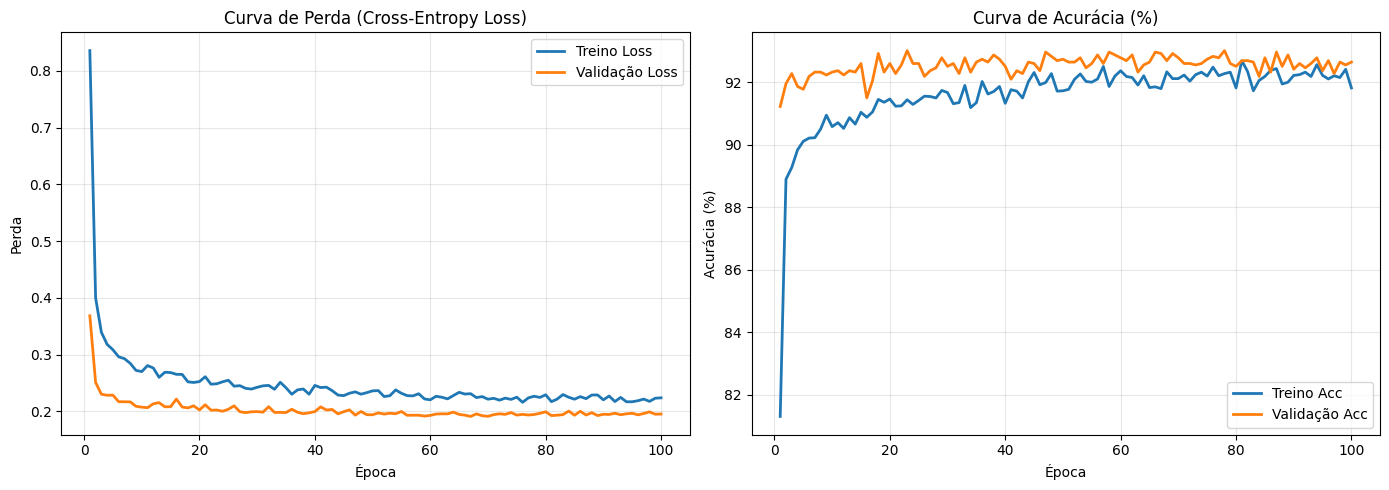

In [103]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Treino Loss", lw=2)
plt.plot(epochs_range, history["val_loss"], label="Validação Loss", lw=2)
plt.title("Curva de Perda (Cross-Entropy Loss)")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history["train_acc"]], label="Treino Acc", lw=2)
plt.plot(epochs_range, [acc * 100 for acc in history["val_acc"]], label="Validação Acc", lw=2)
plt.title("Curva de Acurácia (%)")
plt.xlabel("Época")
plt.ylabel("Acurácia (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

    BARBUNYA       0.96      0.89      0.92       213
      BOMBAY       1.00      1.00      1.00        83
        CALI       0.94      0.95      0.94       261
    DERMASON       0.90      0.94      0.92       570
       HOROZ       0.96      0.95      0.96       304
       SEKER       0.96      0.96      0.96       323
        SIRA       0.87      0.85      0.86       424

    accuracy                           0.93      2178
   macro avg       0.94      0.94      0.94      2178
weighted avg       0.93      0.93      0.93      2178



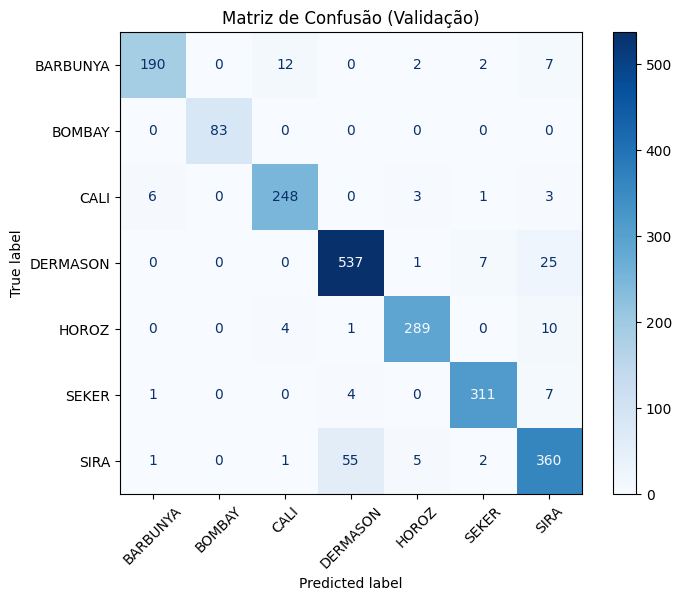

In [104]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())


print(classification_report(all_targets, all_preds, target_names=encoder.classes_))

cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusão (Validação)")
plt.show()


## 5. Inferência no Conjunto de Teste e Geração da Submissão

Conforme as regras da competição:
* O arquivo deve ser um `.csv` com uma única coluna chamada `Class`.
* Conter exatamente 2.723 linhas (além do cabeçalho).
* As classes devem estar em caixa alta (`SEKER`, `BARBUNYA`, etc.).

In [105]:
X_test_scaled = scaler.transform(df_test)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, test_preds = torch.max(test_outputs, 1)

test_preds_labels = encoder.inverse_transform(test_preds.cpu().numpy())

df_submission = pd.DataFrame({"Class": test_preds_labels})
submission_file = "submission.csv"
df_submission.to_csv(submission_file, index=False)

print(f"Total de linhas: {len(df_submission)} (esperamos que seja 2723)")
print(df_submission.head())
print("\nDistribuição das predições no teste:")
print(df_submission["Class"].value_counts())


Total de linhas: 2723 (esperamos que seja 2723)
      Class
0     SEKER
1     SEKER
2     HOROZ
3  BARBUNYA
4      CALI

Distribuição das predições no teste:
Class
DERMASON    737
SIRA        490
SEKER       412
HOROZ       397
CALI        338
BARBUNYA    243
BOMBAY      106
Name: count, dtype: int64
